In [1]:
import sys
import numpy as np
import anndata as ad
import polars as pl
import pickle

import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rna = ad.read_h5ad('private/data/glue/rna_2025_full.h5ad')
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')

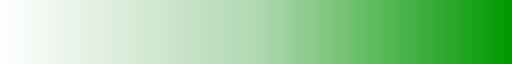

In [3]:
cmap_g = scit.adv.pl.custom_cmap('gray')
cmap_bwr = scit.adv.pl.custom_cmap('bwr')
cmap_c = scit.adv.pl.custom_cmap('with_color')
cmap_c

In [4]:
#active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()
lc_active = scit.tl.make_layer_config('neighborhood_meth_active', feature_active_threshold=0, in_obsm=True)
active_meth = scit.adv.binary_active_feature(cttag, lc_active)

In [5]:
lc_rna = scit.tl.make_layer_config(
    "rna",
    normalize_with_obs_counts=True,
    log_transform=True,
    feature_names=rna.var_names
)
lc_acet = scit.tl.make_layer_config(
    "acet_imp",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth_imp",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)


In [6]:
rna_means = scit.tl.get_layer_feature_means(rna, lc_rna)
rna_means = dict(zip(lc_rna.feature_names, rna_means))

Info: Added Griddata to .uns[cat_label]
Info: Added Griddata to .uns[cat_label_own]


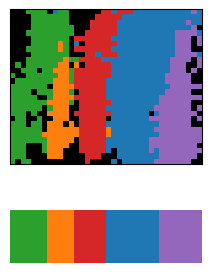

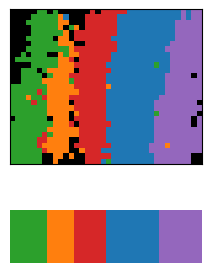

In [7]:
scit.set_defaults(figsize=(2,3))
scit.adv.same_grid((cttag, rna))
scit.adv.griddata_categorical(cttag, 'label', 8)
scit.adv.griddata_categorical(rna, 'label_own', 50)
scit.adv.pl.categorical2d(cttag, 'cat_label')
scit.adv.pl.categorical2d(rna, 'cat_label_own')

In [8]:
s = cttag.uns['gene_names_acet'][active_meth]
scit.tl.layer_pick_features(rna, lc_rna, s)
scit.tl.layer_pick_features(cttag, lc_acet, s)
scit.tl.layer_pick_features(cttag, lc_meth, s)

scit.adv.griddata_numerical(cttag, lc_meth, min_cells=8)
scit.adv.griddata_numerical(cttag, lc_acet, min_cells=8)
scit.adv.griddata_numerical(rna, lc_rna, min_cells=50)

Info: Added Griddata to .uns[meth_imp]
Info: Added Griddata to .uns[acet_imp]
Info: Added Griddata to .uns[rna]


In [9]:
trs = dict(
    gauss_kernel=(1.5,1.5), upscale_factor=2, n_median_passes=1
)

scit.adv.griddata_apply_transformations(cttag, lc_meth.layer, data_scalar=30, **trs)
scit.adv.griddata_apply_transformations(cttag, lc_acet.layer, data_scalar=5, **trs)
scit.adv.griddata_apply_transformations(rna, lc_rna.layer, **trs)

t_acet = f"t_{lc_acet.layer}"
t_meth = f"t_{lc_meth.layer}"
t_rna = f"t_{lc_rna.layer}"

from copy import deepcopy
ACET_SCL = 2

cttag.uns['griddata']['t_epi'] = deepcopy(cttag.uns['griddata'][t_meth])
cttag.uns['griddata']['t_epi']['z'] = cttag.uns['griddata'][t_meth]['z'] - ACET_SCL*cttag.uns['griddata'][t_acet]['z']

Info: Scaling by 2x: from (36, 29) to (72, 58)
Info: Added Griddata to .uns[t_meth_imp]
Info: Scaling by 2x: from (36, 29) to (72, 58)
Info: Added Griddata to .uns[t_acet_imp]
Info: Scaling by 2x: from (36, 29) to (72, 58)
Info: Added Griddata to .uns[t_rna]


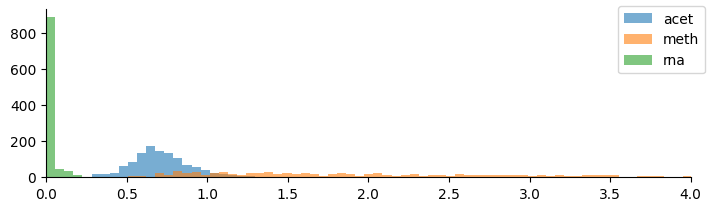

In [10]:
scit.set_defaults(figsize=(7,2))
scit.pl.int.histogram(
    [
    cttag.uns['griddata'][t_acet]['z'].mean(axis=(1,2)),
    cttag.uns['griddata'][t_meth]['z'].mean(axis=(1,2)),
    rna.uns['griddata'][t_rna]['z'].mean(axis=(1,2))
    ],
    [
        'acet', 'meth', 'rna'
    ], xminmax=(0,4), bins=300
)

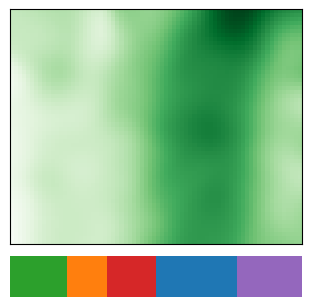

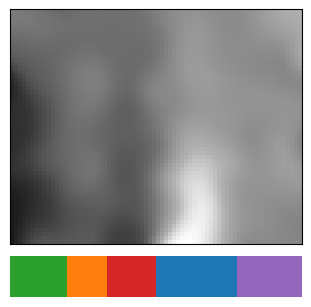

In [11]:
scit.set_defaults(figsize=(3,3))

gn = "vvl"

scit.adv.pl.landscape2d(rna, t_rna, gn, cmap='Greens')
scit.adv.pl.landscape2d(cttag, 't_epi', gn, cmap=cmap_g)

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


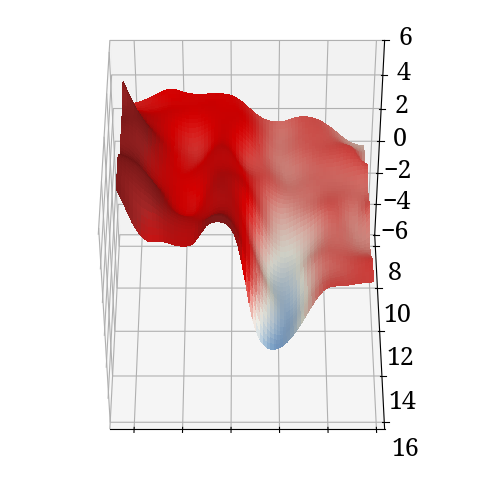

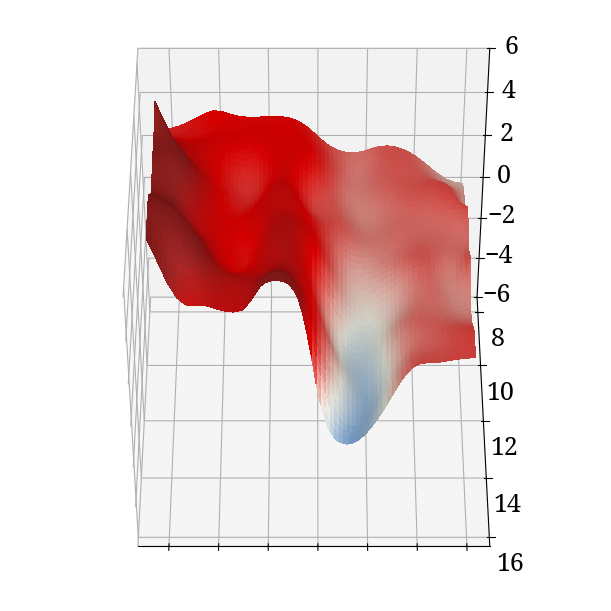

In [12]:
scit.adv.pl.landscape3d(
    cttag.uns['griddata']['t_epi'], gn, cmap=cmap_bwr,  vminmax=(-6,6),
    ticksize=18, show=False, fontname="Noto Serif", label_pad=6#fontname="FreeMono"
)#.savefig(f'private/newest/screenshots/{gn}_epi.png', dpi=500)

RNA range: (0.0003706318966578692, 0.043840356171131134)


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


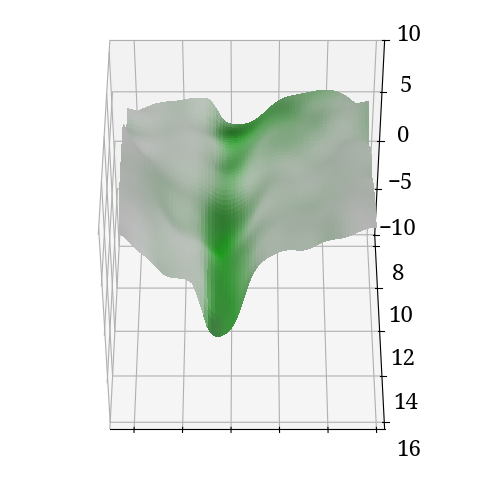

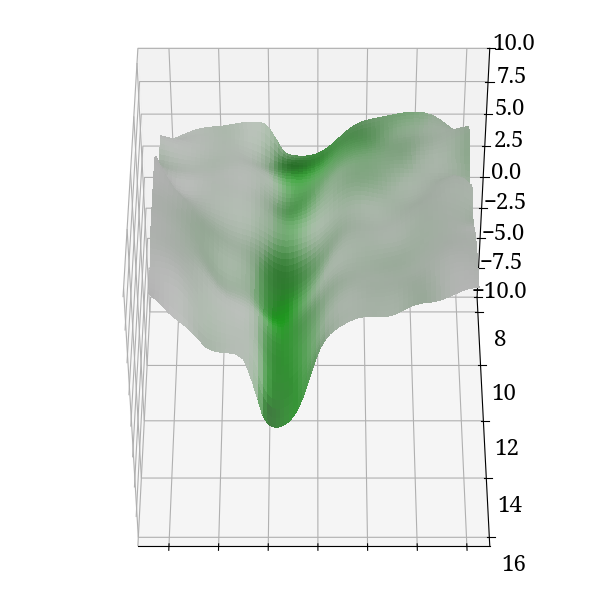

In [15]:
scit.set_defaults(figsize=(3,3))
# scit.adv.pl.landscape3d(cttag, 't_epi', gn, cmap=cmap_g, vminmax=(0,20))
#v_sh = None#(0,0.04)#(0,0.12) <- acj6
qmax = 0.99
scit.adv.pl.landscape3d(
    cttag.uns['griddata']['t_epi'], 'so', cmap=cmap_g,  vminmax=(-10,10), ticksize=16,
    show=False, fontname="Noto Serif", label_pad=8,
    shade_data=rna.uns['griddata'][t_rna], shade_cmap=cmap_c, extra_shade_weight=2, shade_qmax=qmax #shade_vminmax=(0,7), 
)#.savefig(f'private/newest/screenshots/{gn}_rna.png', dpi=500)

#scit.set_defaults(figsize=(10,3))
#scit.adv.pl.draw_cbar(cmap_c, vminmax=v_sh).savefig(f'private/newest/screenshots/vvl_rna_cbar.pdf')

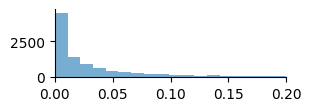

In [19]:
scit.set_defaults(figsize=(3,1))
scit.pl.int.histogram(np.array(list(rna_means.values())),xminmax=(0,0.2),bins=300)

In [21]:
scit.set_defaults(figsize=(3,3))
from src.advanced._griddata import _get_griddata_z
import matplotlib.pyplot as plt
qmax = 0.9
import os

for gn in rna.uns['griddata']['t_rna']['feature_names']:
    if gn not in rna_means:
        continue
    if rna_means[gn] < 0.01:
        continue
    if os.path.isfile(f'private/newest/lands/{gn}_rna.png'):
        continue
    z = _get_griddata_z(cttag.uns['griddata']['t_epi'], gn)
    vminmax = (-2,2)
    while np.abs(z).max() > vminmax[1]:
        vminmax = (vminmax[0]-1, vminmax[1]+1)
    f=scit.adv.pl.landscape3d(
        cttag.uns['griddata']['t_epi'], gn, cmap=cmap_g, vminmax=vminmax, ticksize=16,
        show=False, fontname="Noto Serif", label_pad=8,
        shade_data=rna.uns['griddata'][t_rna], shade_cmap=cmap_c, extra_shade_weight=2, shade_vminmax=(0,0), shade_qmax=qmax #shade_vminmax=(0,7), 
    )
    f.savefig(f'private/newest/lands/{gn}_rna.png', dpi=400)
    del f
    del z
    plt.close('all')
    import gc; gc.collect()

#scit.set_defaults(figsize=(10,3))
#scit.adv.pl.draw_cbar(cmap_c, vminmax=v_sh).savefig(f'private/newest/screenshots/vvl_rna_cbar.pdf')

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/tmp/nix-shell-365654-0/ipykernel_382963/2806445.py:23: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  f.savefig(f'private/newest/lands/{gn}_rna.png', dpi=400)
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/tmp/nix-shell-365654-0/ipykernel_382963/2806445.py:23: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  f.savefig(f'private

In [11]:
#from copy import deepcopy
#cttag.uns['griddata']['acet_metabin'] = deepcopy(cttag.uns['griddata']['t_acet'])
#cttag.uns['griddata']['acet_metabin']['z'] = cttag.uns['griddata']['acet_metabin']['z']

In [16]:
s = 'vvl'
scit.tl.layer_pick_features(rna, lc_rna, s)

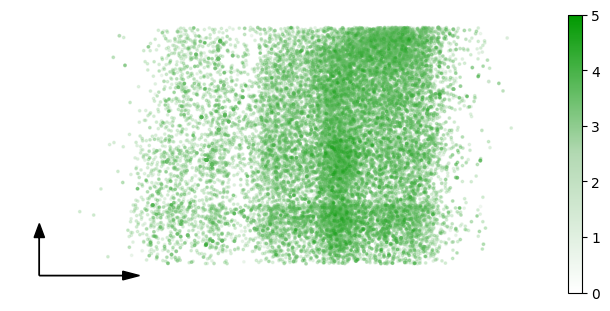

In [24]:
scit.tl.copy_to_obs(rna, lc_rna)
scit.set_defaults(figsize=(6,3))
scit.pl.embedding2d(rna, 'X_landscape', 'copied_data', cmap=cmap_c, vminmax=(0,5), alpha=0.2, show=False).savefig('private/newest/screenshots/vvl_rna.png', dpi=500)